In [1]:
import matplotlib.pyplot as plt
import torch

In [2]:
words = []
with open("names.txt","r") as f:
    words = f.read().splitlines()

In [3]:
len(words)

32033

In [4]:
words[:4]

['emma', 'olivia', 'ava', 'isabella']

In [5]:
#look for the bigrams in the first word
for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        print(ch1,ch2)

. e
e m
m m
m a
a .


In [6]:
#goal generate new names from the existing names and model the above dataset as bigram(probablities)
#ex. .danish. for this we want prob(.d)*prob(da)*prob(an)*prob(ni)*prob(is)*prob(sh)*prob(h.)
#where prob(AlphaBeta) means given character alpha occured what is the prob of occurence of character Beta

In [7]:
chars = set(''.join(words))
chars = list(chars)
chars.sort()
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [8]:
stoi = {c:i+1 for i,c in enumerate(chars)}
stoi['.'] = 0
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [9]:
itos = {i:c for c,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

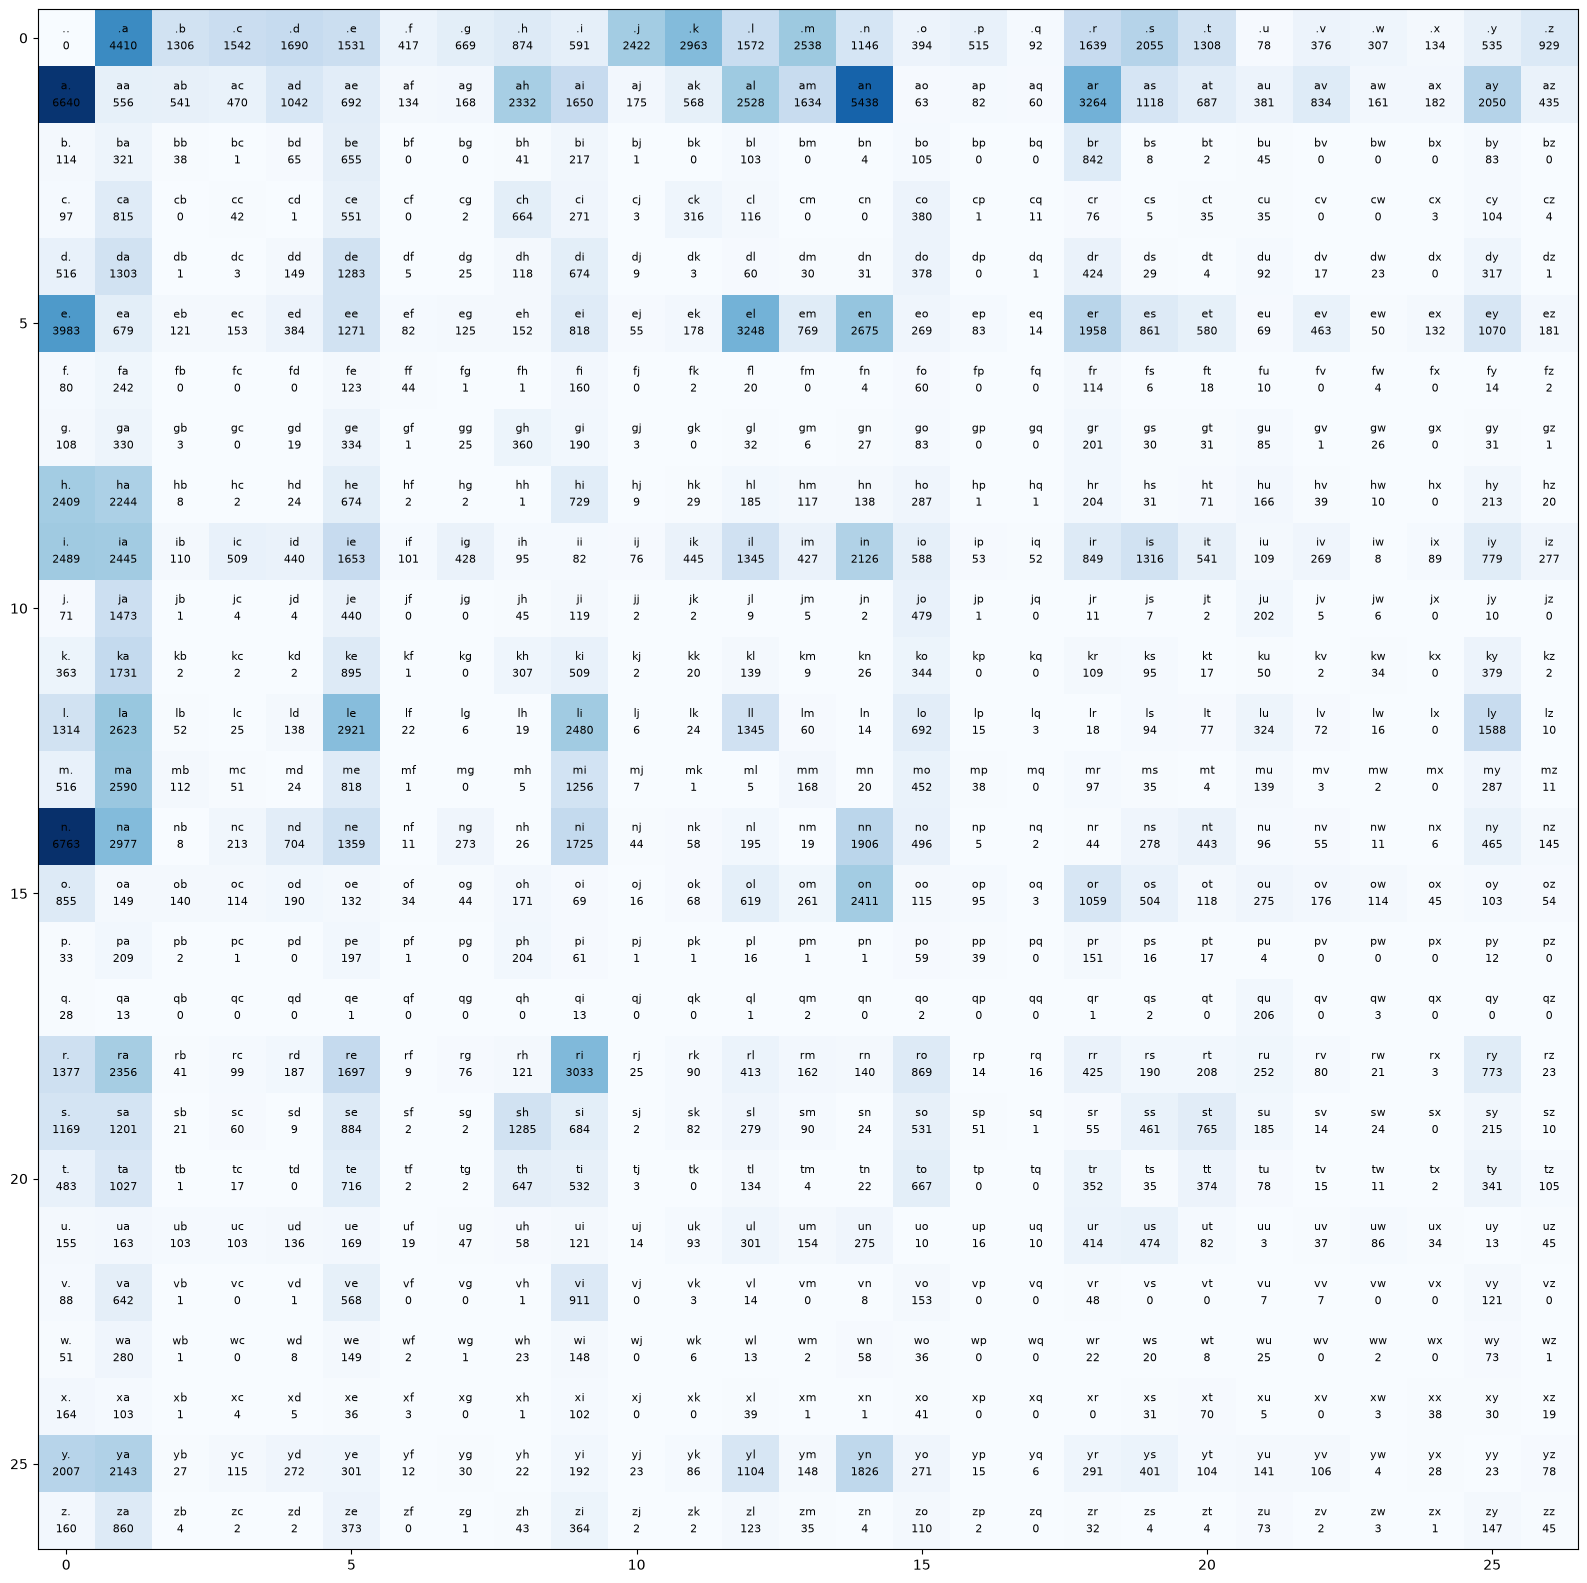

In [10]:
#let's get the counts of all the possible bigrams
N = torch.zeros((27,27),dtype = int)
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        N[ix1,ix2] += 1
plt.figure(figsize=(20,20))
plt.imshow(N, cmap = 'Blues')

for i in range(27):
    for j in range(27):

        # bigram
        plt.text(
            j, i - 0.15,
            itos[i] + itos[j],
            ha='center',
            va='center',
            fontsize=8
        )

        # count
        plt.text(
            j, i + 0.15,
            int(N[i, j].item()),
            ha='center',
            va='center',
            fontsize=8
        )

plt.show()


In [11]:
#Now we convert the above rows into prob vectors
N += 1 #model smoothing
counts = N.sum(1,keepdim=True,dtype=float)
counts.dtype

torch.float64

In [12]:

N = N.float()
N /= counts 
N[0].sum()

tensor(1.)

In [13]:
print(N.shape)
print(N[0].shape)

torch.Size([27, 27])
torch.Size([27])


In [15]:
#let's now produce new names using the above model
ix = 0
while True:
   
    p = N[ix]
    p.shape
    ix = torch.multinomial(p,num_samples=1,replacement=True).item()
    print(itos[ix])
    if ix == 0:
        break


e
y
.


In [16]:
#let's now check the probability assigned to one of the training examples
#log(a*b*c) = log(a) + log(b) + log(c)
for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    likelihood = 1.0
    loglikelihood = 0
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        print(ch1,ch2)
        likelihood *= N[ix1,ix2]
        loglikelihood += N[ix1,ix2].log()
    print(likelihood.item())
    nll = -1*loglikelihood.item()
    print(nll)

. e
e m
m m
m a
a .
3.4690092434175313e-06
12.57164192199707


In [17]:
#calculating negative mean logLikelihood of the entire training set is the accuracy
#we want from the neural network that we are going to train next
likelihood = 1.0
loglikelihood = 0
count = 0
for w in words:
    chs = ["."] + list(w) + ["."]
    
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        # print(ch1,ch2)
        count += 1
        likelihood *= N[ix1,ix2]
        loglikelihood += N[ix1,ix2].log()
print(likelihood.item())
nll = -1*loglikelihood.item()/count
print(nll)

0.0
2.4543562565199477


You got:

$$ \text{mean NLL} = 2.454094 $$

for your count-based bigram model.

That gives you a useful baseline.

But you can get lower than 2.454 with a neural network.

Why? Because your count-based model is already the maximum-likelihood solution for this particular bigram model on the training data. If the neural network is learning exactly the same unrestricted 27×27 bigram probability table, then its best possible training NLL should approach the same value:

$$ \boxed{2.454094} $$

It shouldn't systematically beat the exact frequency-based solution for the same bigram model.

However, if you train the neural network with a different model architecture or additional structure, the situation changes.

In [18]:
#let's try predicting another word that is very unlikely to be produced
for w in ["danishjzpk"]:
    chs = ["."] + list(w) + ["."]
    
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        # print(ch1,ch2)
        count += 1
        likelihood *= N[ix1,ix2]
        loglikelihood += N[ix1,ix2].log()
print(likelihood.item())
nll = -1*loglikelihood.item()/count
print(nll)

0.0
2.4544274885276365


In [19]:
#as we can see above we got infinity and zero probability,we don't want this to happen
#for any word, so let's introduce model smoothing
#let's try predicting another word that is very unlikely to be produced
for w in ["danishjzpk"]:
    chs = ["."] + list(w) + ["."]
    
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        # print(ch1,ch2)
        count += 1
        likelihood *= N[ix1,ix2]
        loglikelihood += N[ix1,ix2].log()
print(likelihood.item())
nll = -1*loglikelihood.item()/count
print(nll) #the below result we got after model smoothing

0.0
2.4544987136671224


## Training The Neural Net using the same bigram data as we have available above

In [36]:
#one hot encoding for the characters
import torch.nn.functional as F
characters = torch.tensor([0,1,2])
charenc = F.one_hot(characters,num_classes=3)
print(charenc)

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]])


In [37]:
#let's first train a simple neural network using a single example emma
x_input = []
y_output = []
# x = torch.zeros((27,5))
# y = torch.zeros((27,5))
for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        x_input.append(ix1)
        y_output.append(ix2)
print(x_input)
print(y_output)
x = torch.tensor(x_input,dtype = torch.long)
y = torch.tensor(y_output,dtype = torch.long)
xenc = F.one_hot(x,num_classes=27).float()
xenc.dtype
# print(xenc)

print(torch.arange(len(x)))

[0, 5, 13, 13, 1]
[5, 13, 13, 1, 0]
tensor([0, 1, 2, 3, 4])


In [38]:
#define the weights for all the 27 neurons
W = torch.zeros((27,27))

#pass all the examples in x in parallel through the network
logits = xenc @ W
#try to make each row of pred give probablities of (.,a,b,c,d,.....,z)
counts = logits.exp()
counts /= counts.sum(1,keepdim = True)
probs = counts



In [39]:
probs[0,5],probs[1,13],probs[2,13],probs[3,1],probs[4,0]

(tensor(0.0370),
 tensor(0.0370),
 tensor(0.0370),
 tensor(0.0370),
 tensor(0.0370))

In [40]:
#calculating training loss
#using the y to index into the probs array
probs[torch.arange(len(x)),y]
#calculate the loss of the negative log likelihood
loglikelihood = 0.0
for el in probs[torch.arange(len(x)),y]:
    loglikelihood += torch.log(el)
nll = -loglikelihood
print(nll)

tensor(16.4792)


In [41]:
#repeating the same above process for the entire dataset
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1,ix2 = stoi[ch1],stoi[ch2]
        x_input.append(ix1)
        y_output.append(ix2)
# print(x_input)
# print(y_output)
x = torch.tensor(x_input,dtype = torch.long)
y = torch.tensor(y_output,dtype = torch.long)
xenc = F.one_hot(x,num_classes=27).float()
#define the weights for all the 27 neurons

W = torch.zeros((27,27))
#pass all the examples in x in parallel through the network
logits = xenc @ W
#try to make each row of pred give probablities of (.,a,b,c,d,.....,z)
counts = logits.exp()
counts /= counts.sum(1,keepdim = True)
probs = counts

loglikelihood = 0.0
n = 0
for el in probs[torch.arange(len(x)),y]:
    loglikelihood += math.log(el)
    n += 1
nll = -loglikelihood
print(nll/n)
# nll = torch.tensor(nll,requires_grad=True)
# nll.backward()
    

3.295836858565252


In [43]:
#define the weights for all the 27 neurons
W = torch.zeros((27,27),requires_grad= True)

In [161]:

for k in range(10):
    #FORWARD PASS
    x_input = []
    y_output = []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1,ch2 in zip(chs,chs[1:]):
            ix1,ix2 = stoi[ch1],stoi[ch2]
            x_input.append(ix1)
            y_output.append(ix2)
    # print(x_input)
    # print(y_output)
    x = torch.tensor(x_input,dtype = torch.long)
    y = torch.tensor(y_output,dtype = torch.long)
    xenc = F.one_hot(x,num_classes=27).float()


    
    #pass all the examples in x in parallel through the network
    logits = xenc @ W
    #try to make each row of pred give probablities of (.,a,b,c,d,.....,z)
    counts = logits.exp()
    probs = counts/counts.sum(1,keepdim = True)
  

    loglikelihood = 0.0
    # n = 0
    # for el in probs[torch.arange(len(x)),y]:
    #     loglikelihood += torch.log(el)
    # n += 1
    # nll = -loglikelihood
    # loss = nll
    
    lammda = 0.01 #regulaization : equivalent to smoothing
    loglikelihood = torch.log(probs[torch.arange(len(x)), y]).mean() 
    nll = -loglikelihood
    loss = nll + lammda*(W**2).mean() #penalizes large weights
# print(nll/n)

#BACKWARD PASS
    loss.backward()

#UPDATE The Weights
    learning_rate = 50
    W.data += -learning_rate*W.grad

#zero grad
    W.grad.zero_()
    print(loss.item())



2.480473756790161
2.480473041534424
2.4804725646972656
2.4804718494415283
2.480471134185791
2.480470657348633
2.4804701805114746
2.4804697036743164
2.480468988418579
2.480468273162842


In [196]:
#finally let's sample from the neural net model
#let's now produce new names using the above model
output = []
for i in range(5):
    ix = 0
    word = []
    while True:
    
        p = N[ix]
        p.shape
        ix = torch.multinomial(p,num_samples=1,replacement=True).item()
        word.append(itos[ix])
        if ix == 0:
            break
    output.append(''.join(word))
print(output)

['n.', 'arionnumate.', 'a.', 'si.', 'nys.']


In [182]:
#finally let's sample from the neural net model
#let's now produce new names using the above model
output = []
for i in range(5):
    ix = 0
    word = []
    while True:
    
        xenc = F.one_hot(torch.tensor([ix]),num_classes=27).float()
        logits = xenc @ W
            #try to make each row of pred give probablities of (.,a,b,c,d,.....,z)
        counts = logits.exp()
        probs = counts/counts.sum(1,keepdim = True)
        p = probs
        ix = torch.multinomial(p,num_samples=1,replacement=True).item()
        word.append(itos[ix])
        if ix == 0:
            break
    output.append(''.join(word))
print(output)

['neqmavanayn.', 'pearloloahien.', 'entey.', 'pjadesrbvrynah.', 'kh.']


In [200]:
#take a moment to realize that W.exp() = N